# DSN Preprocessing — Daily RMS and Phase Scintillation

This notebook combines the large-scale Doppler RMS diagnostics and the phase scintillation preprocessing pipeline into a single workflow.

---

## Workflow

### SECTION 1 — Daily Doppler RMS Diagnostics

1. Load DSN Doppler data
2. Apply quality filtering
3. Compute daily Doppler RMS
4. Merge with solar elongation (SEP)
5. Compare against DSN solar scintillation model
6. Add seasonal tropospheric model
7. Generate large-scale diagnostic plots

---

### SECTION 2 — Phase Scintillation Window Construction

This notebook converts Doppler residuals into phase fluctuations and computes band-limited phase scintillation using a spectral (PSD-based) method.

---

## Method

The processing steps are:

1. Load filtered Doppler data
2. Convert Doppler frequency → phase:
   
   φ(t) = 2π ∫ f(t) dt

3. Segment data into overlapping time windows:
   - window length: 20 minutes
   - step size: 10 minutes

4. For each window:
   - compute power spectral density (Welch method)
   - integrate PSD over the scintillation band:
     
     3×10⁻⁴ Hz to 3×10⁻² Hz

5. Compute band-limited phase RMS for each window

---

## Output

This notebook produces:

- `phase_windows_<year>.csv`

Each row represents a time window with:

- phase RMS (rad)
- number of samples
- window timing

This dataset is the core input for CIR and CME detection.
---

## Outputs

This notebook produces:

- `daily_metrics_<year>.csv`
- `phase_windows_<year>.csv`

These outputs form the input to the CIR and CME detection pipeline.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings_2014 import *

deBug = True
sav_file = True

from src.io_utils import (
    load_dsn_data,
    load_horizons_daily_sep,
    remove_known_bad_tracking_intervals,
)

from src.doppler_utils import (
    prepare_daily_rms_table,
    print_daily_summary,
    add_seasonal_troposphere_model,
)

from src.phase_utils import (
    compute_phase_rms_windows,
    print_phase_summary,
)

from src.plot_utils import (
    plot_daily_rms_vs_sep,
    plot_phase_scintillation_time_series,
)

debug= True
save_file = True

# SECTION 1 — Daily Doppler RMS Diagnostics

In [2]:
horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)

df = load_dsn_data(
    DOPPLER_FILE,
    valid_only=USE_VALID_FLAG,
    min_elev_deg=MIN_ELEV_DEG,
    max_abs_doppler_hz=MAX_ABS_DOPPLER_HZ,
)
df = remove_known_bad_tracking_intervals(
    df,
    year=YEAR,
    time_col="UTC_time",
    verbose=True,
)
if debug:

    print("Horizons rows:", len(horizons_daily))
    print(
        "Horizons range:",
        horizons_daily["day"].min(),
        "→",
        horizons_daily["day"].max(),
    )

    print("DSN rows:", len(df))
    print(
        "DSN range:",
        df["UTC_time"].min(),
        "→",
        df["UTC_time"].max(),
    )

[QC] Removing 2014 bad tracking interval 2014-05-20 → 2014-05-31 | rows removed: 26440
[QC] Rows after removal: 238077
Horizons rows: 365
Horizons range: 2014-01-01 00:00:00 → 2014-12-31 00:00:00
DSN rows: 238077
DSN range: 2014-01-01 10:07:53.112000 → 2014-06-04 17:05:39.955000


In [3]:
# ============================================================
# LOAD HORIZONS + DSN DATA
# ============================================================

horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)

df = load_dsn_data(
    DOPPLER_FILE,
    valid_only=USE_VALID_FLAG,
    min_elev_deg=MIN_ELEV_DEG,
    max_abs_doppler_hz=MAX_ABS_DOPPLER_HZ,
)

# ============================================================
# APPLY KNOWN BAD DSN TRACKING INTERVAL QC
# ============================================================

from src.io_utils import remove_known_bad_tracking_intervals

df = remove_known_bad_tracking_intervals(
    df=df,
    year=YEAR,
    time_col="UTC_time",
    verbose=True,
)

# ------------------------------------------------------------
# QC CHECK
# ------------------------------------------------------------

print("\nAfter known-bad interval QC:")
print("Rows entering processing:", len(df))
print("Date range:", df["UTC_time"].min(), "→", df["UTC_time"].max())
print("Max |doppler|:", df["doppler"].abs().max())
print("Frac |doppler| > 0.25:", (df["doppler"].abs() > 0.25).mean())

check_bad = df[
    (df["UTC_time"] >= "2014-05-20") &
    (df["UTC_time"] <= "2014-05-31")
]

print("Rows inside removed bad interval:", len(check_bad))

if debug:
    print("Horizons rows:", len(horizons_daily))
    print(
        "Horizons range:",
        horizons_daily["day"].min(),
        "→",
        horizons_daily["day"].max(),
    )

    print("DSN rows:", len(df))
    print(
        "DSN range:",
        df["UTC_time"].min(),
        "→",
        df["UTC_time"].max(),
    )

[QC] Removing 2014 bad tracking interval 2014-05-20 → 2014-05-31 | rows removed: 26440
[QC] Rows after removal: 238077

After known-bad interval QC:
Rows entering processing: 238077
Date range: 2014-01-01 10:07:53.112000 → 2014-06-04 17:05:39.955000
Max |doppler|: 0.238773513
Frac |doppler| > 0.25: 0.0
Rows inside removed bad interval: 0
Horizons rows: 365
Horizons range: 2014-01-01 00:00:00 → 2014-12-31 00:00:00
DSN rows: 238077
DSN range: 2014-01-01 10:07:53.112000 → 2014-06-04 17:05:39.955000


In [4]:
daily_df = prepare_daily_rms_table(
    dsn_df=df,
    horizons_daily=horizons_daily,
    f_carrier_hz=F_CARRIER,
    c_mps=C,
    T_int_sec=T_INT,
    C_band=C_BAND,
    resample_rule=RESAMPLE_RULE,
    min_samples_per_day=MIN_SAMPLES_PER_DAY,
    smooth_days=SMOOTH_DAYS,
    add_tropo_diagnostic=False,
)

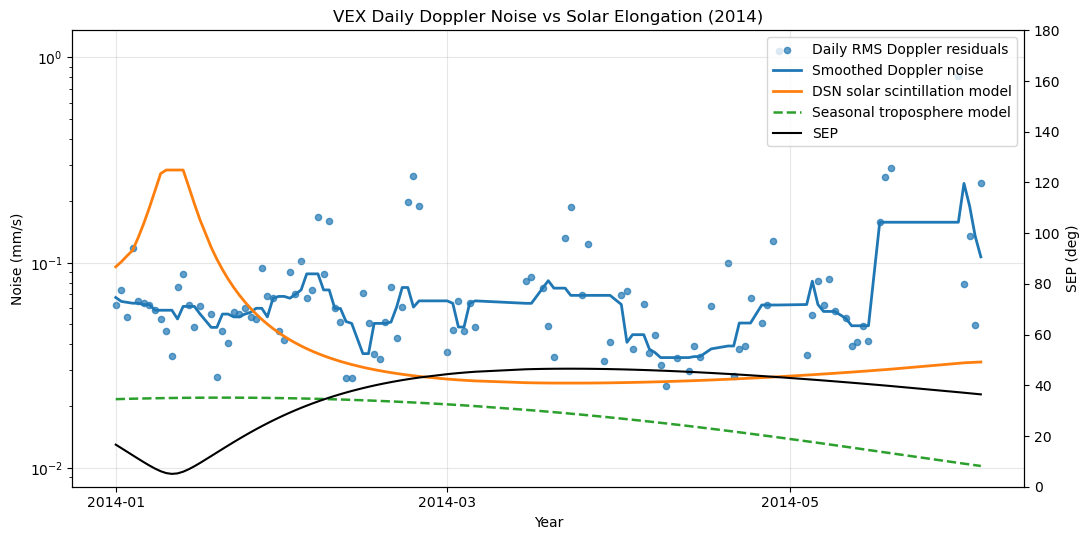

In [5]:
daily_df = add_seasonal_troposphere_model(
    daily_df=daily_df,
    amplitude_mm_s=TROPO_AMP,
    offset_mm_s=TROPO_OFFSET,
    phase_day=TROPO_PHASE_DAY,
    smooth_days=SMOOTH_DAYS,
)

fig, axes = plot_daily_rms_vs_sep(
    daily_df=daily_df,
    year=YEAR,
)

plt.show()

In [6]:
if save_file:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    daily_csv = (
        OUTPUT_DIR
        / f"daily_metrics_{YEAR}.csv"
    )

    daily_df.to_csv(
        daily_csv,
        index=False,
    )

    print("Saved:", daily_csv)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/daily_metrics_2014.csv


In [7]:
if debug:

    print(daily_df.columns.tolist())

    display(daily_df.tail())

['day', 'doppler_rms_mm_s', 'n_60s_samples', 'elongation_deg', 'solar_model_mm_s', 'decimal_year', 'doppler_smooth_mm_s', 'solar_smooth_mm_s', 'doy', 'tropo_seasonal_mm_s', 'tropo_seasonal_smooth_mm_s']


,day,doppler_rms_mm_s,n_60s_samples,elongation_deg,solar_model_mm_s,decimal_year,doppler_smooth_mm_s,solar_smooth_mm_s,doy,tropo_seasonal_mm_s,tropo_seasonal_smooth_mm_s
106,2014-05-31,0.812681,525,37.2771,0.032333,2014.410678,0.157470,0.032333,151,0.010224,0.010224
107,2014-06-01,0.078974,624,37.0660,0.032526,2014.413415,0.243435,0.032526,152,0.009926,0.009926
108,2014-06-02,0.134537,628,36.8537,0.032722,2014.416153,0.188986,0.032624,153,0.009630,0.009778
109,2014-06-03,0.049503,285,36.6401,0.032923,2014.418891,0.134537,0.032722,154,0.009337,0.009630
110,2014-06-04,0.243435,92,36.4253,0.033128,2014.421629,0.106755,0.032823,155,0.009048,0.009484


# SECTION 2 — Phase Scintillation Window Construction

Computing phase windows...
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_2014.csv
Windows created: 4065
Window time range: 2014-01-01 10:07:50 → 2014-06-04 16:57:50
Phase RMS range (rad): 0.06483397709976174 → 22.227667474190255


,start,end,mid,phase_rms_rad,n_samples,elongation_deg
0,2014-01-01 10:07:50,2014-01-01 10:27:50,2014-01-01 10:17:50,2.297264,120,16.009167
1,2014-01-01 10:17:50,2014-01-01 10:37:50,2014-01-01 10:27:50,1.239110,120,15.999593
2,2014-01-01 10:27:50,2014-01-01 10:47:50,2014-01-01 10:37:50,0.465645,120,15.990019
3,2014-01-01 10:37:50,2014-01-01 10:57:50,2014-01-01 10:47:50,0.378426,120,15.980445
4,2014-01-01 10:47:50,2014-01-01 11:07:50,2014-01-01 10:57:50,0.673374,120,15.970870


['start', 'end', 'mid', 'phase_rms_rad', 'n_samples', 'elongation_deg']


,start,end,mid,phase_rms_rad,n_samples,elongation_deg
4060,2014-06-04 15:57:50,2014-06-04 16:17:50,2014-06-04 16:07:50,0.405727,70,36.280058
4061,2014-06-04 16:07:50,2014-06-04 16:27:50,2014-06-04 16:17:50,0.361352,68,36.278557
4062,2014-06-04 16:17:50,2014-06-04 16:37:50,2014-06-04 16:27:50,0.141506,58,36.277056
4063,2014-06-04 16:27:50,2014-06-04 16:47:50,2014-06-04 16:37:50,0.191333,50,36.275556
4064,2014-06-04 16:37:50,2014-06-04 16:57:50,2014-06-04 16:47:50,0.139945,62,36.274055


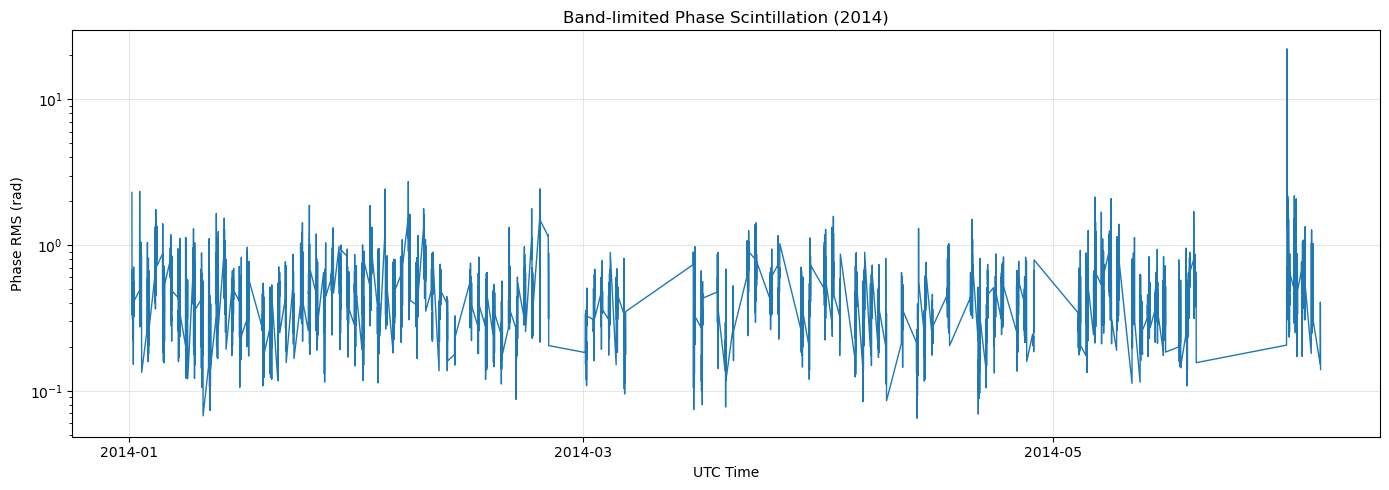

Number of windows: 4065
Phase RMS min: 0.06483397709976174
Phase RMS median: 0.41897052912737454
Phase RMS max: 22.227667474190255
Median samples per window: 120.0


In [8]:
# ============================================================
# SECTION 2 — Phase scintillation windows
# ============================================================

phase_csv = OUTPUT_DIR / f"phase_windows_{YEAR}.csv"

FORCE_RECOMPUTE_PHASE = True

if phase_csv.exists() and not FORCE_RECOMPUTE_PHASE:

    print("Loading cached phase windows:", phase_csv)

    windows_df = pd.read_csv(phase_csv)

    for col in ["start", "end", "mid"]:
        windows_df[col] = pd.to_datetime(windows_df[col])

else:

    print("Computing phase windows...")

    windows_df = compute_phase_rms_windows(
        df,
        time_col="UTC_time",
        doppler_col="doppler",
        dt_target_sec=DT_TARGET,
        window_min=WINDOW_MIN,
        step_min=STEP_MIN,
        min_samples=MIN_SAMPLES,
        f_low_hz=F_LOW,
        f_high_hz=F_HIGH,
    )

    geom = horizons_daily.set_index("day")

    windows_df["elongation_deg"] = np.interp(
        windows_df["mid"].astype("int64"),
        geom.index.astype("int64"),
        geom["elongation_deg"],
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    windows_df.to_csv(phase_csv, index=False)

    print("Saved:", phase_csv)

if deBug:
    print_phase_summary(windows_df)
    display(windows_df.head())
    print(windows_df.columns.tolist())
    display(windows_df.tail())

fig, ax = plot_phase_scintillation_time_series(windows_df, year=YEAR)
plt.show()

if debug:

    valid = windows_df["phase_rms_rad"].dropna()

    print("Number of windows:", len(windows_df))
    print("Phase RMS min:", valid.min())
    print("Phase RMS median:", valid.median())
    print("Phase RMS max:", valid.max())

    print(
        "Median samples per window:",
        windows_df["n_samples"].median(),
    )

In [13]:
if save_file:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    phase_csv = (
        OUTPUT_DIR
        / f"phase_windows_{YEAR}.csv"
    )

    fig_path = (
        OUTPUT_DIR
        / f"phase_scintillation_{YEAR}.png"
    )

    windows_df.to_csv(
        phase_csv,
        index=False,
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight",
    )

    print("Saved:", phase_csv)
    print("Saved:", fig_path)



Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_2014.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_scintillation_2014.png
